#📌 Extração

In [1]:
# Importando biblioteca/pacote/módulo
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [2]:
dados = pd.read_json('/content/TelecomX_Data.json')

In [3]:
# Normalizando dados
df = pd.json_normalize(dados.to_dict('records'), sep="_")
display(df.head(5))

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

#🔧 Transformação

In [5]:
# Removendo registros vazios e espaços da coluna Churn
df = df[df['Churn'].astype(str).str.strip() != ''].copy()

# Converter colunas numéricas
num_cols = ['account_Charges_Monthly', 'account_Charges_Total']
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

# Mapear Yes/No → 1/0 sem FutureWarning
cols_yn = [
    'Churn','customer_Partner','customer_Dependents','phone_PhoneService','phone_MultipleLines',
    'internet_OnlineSecurity','internet_OnlineBackup','internet_DeviceProtection',
    'internet_TechSupport','internet_StreamingTV','internet_StreamingMovies','account_PaperlessBilling'
]
map_dict = {'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0}
df[cols_yn] = df[cols_yn].replace(map_dict).astype(int)

# Criar coluna de cobranças diárias
df['Cobrancas_Diarias'] = df['account_Charges_Monthly'] / 30

# Informações rápidas
print('Dimensão após limpeza:', df.shape)
display(df.head())
print(df.info())


Dimensão após limpeza: (7043, 22)


/tmp/ipykernel_1820/2053460783.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols_yn] = df[cols_yn].replace(map_dict).astype(int)


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,Cobrancas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   int64  
 2   customer_gender            7043 non-null   object 
 3   customer_SeniorCitizen     7043 non-null   int64  
 4   customer_Partner           7043 non-null   int64  
 5   customer_Dependents        7043 non-null   int64  
 6   customer_tenure            7043 non-null   int64  
 7   phone_PhoneService         7043 non-null   int64  
 8   phone_MultipleLines        7043 non-null   int64  
 9   internet_InternetService   7043 non-null   object 
 10  internet_OnlineSecurity    7043 non-null   int64  
 11  internet_OnlineBackup      7043 non-null   int64  
 12  internet_DeviceProtection  7043 non-null   int64  
 13  internet_TechSupport       7043 non-null   int64  
 1

In [6]:
# Verificando
df[cols_yn].apply(lambda x: x.unique())

,Churn,customer_Partner,customer_Dependents,phone_PhoneService,phone_MultipleLines,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_PaperlessBilling
0,0,1,1,1,0,0,1,0,1,1,0,1
1,1,0,0,0,1,1,0,1,0,0,1,0


In [7]:
# Informações de tipos e nulos
print('Tipos de dados e valores nulos:')
df.info()
print('\nQuantidade de valores nulos por coluna:')
print(df.isnull().sum())

Tipos de dados e valores nulos:
<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   int64  
 2   customer_gender            7043 non-null   object 
 3   customer_SeniorCitizen     7043 non-null   int64  
 4   customer_Partner           7043 non-null   int64  
 5   customer_Dependents        7043 non-null   int64  
 6   customer_tenure            7043 non-null   int64  
 7   phone_PhoneService         7043 non-null   int64  
 8   phone_MultipleLines        7043 non-null   int64  
 9   internet_InternetService   7043 non-null   object 
 10  internet_OnlineSecurity    7043 non-null   int64  
 11  internet_OnlineBackup      7043 non-null   int64  
 12  internet_DeviceProtection  7043 non-null   int64  
 13  internet_TechSupport 

In [8]:
# Substituir nulos pela média e mostrar contagem
df.fillna({'account_Charges_Total': df['account_Charges_Total'].mean()}, inplace=True)
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   int64  
 2   customer_gender            7043 non-null   object 
 3   customer_SeniorCitizen     7043 non-null   int64  
 4   customer_Partner           7043 non-null   int64  
 5   customer_Dependents        7043 non-null   int64  
 6   customer_tenure            7043 non-null   int64  
 7   phone_PhoneService         7043 non-null   int64  
 8   phone_MultipleLines        7043 non-null   int64  
 9   internet_InternetService   7043 non-null   object 
 10  internet_OnlineSecurity    7043 non-null   int64  
 11  internet_OnlineBackup      7043 non-null   int64  
 12  internet_DeviceProtection  7043 non-null   int64  
 13  internet_TechSupport       7043 non-null   int64  
 1

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


#📊 Carga e análise

In [9]:
# Analisando proporção
print('Proporção de Churn (%)')
df['Churn'].value_counts(normalize=True).mul(100).reset_index(name='Proporção')

Proporção de Churn (%)


,Churn,Proporção
0,0,73.463013
1,1,26.536987


In [10]:
# Analisando cobrança mensal
print('Valor médio da cobrança mensal entre clientes que permanecem e os que cancelam')
df.groupby('Churn')['account_Charges_Monthly'].mean().reset_index(name='Vlr. Médio')

Valor médio da cobrança mensal entre clientes que permanecem e os que cancelam


,Churn,Vlr. Médio
0,0,61.265124
1,1,74.441332


In [11]:
# Analisando encargos
print('Média do total de encargos da conta')
df.groupby('Churn')['account_Charges_Total'].mean().reset_index(name='Média encargos')

Média do total de encargos da conta


,Churn,Média encargos
0,0,2554.765772
1,1,1531.796094


In [12]:
# Analisando contratos
print('Taxa média de churn (%) por tipo de contrato')
churn_contrato = (
    df.groupby('account_Contract')['Churn']
      .mean()
      .mul(100)
      .reset_index(name='Média contrato')
      .sort_values(by='Média contrato', ascending=False)
)
display(churn_contrato)

Taxa média de churn (%) por tipo de contrato


,account_Contract,Média contrato
0,Month-to-month,42.709677
1,One year,11.269518
2,Two year,2.831858


In [13]:
# Analisando serviços
servicos = [
    'internet_OnlineSecurity',
    'internet_OnlineBackup',
    'internet_DeviceProtection',
    'internet_TechSupport'
]

df.groupby("Churn")[servicos].mean().mul(100).reset_index()

,Churn,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport
0,0,33.320448,36.838036,36.277542,33.513722
1,1,15.783842,27.982879,29.159979,16.586410


#📄Relatório Final

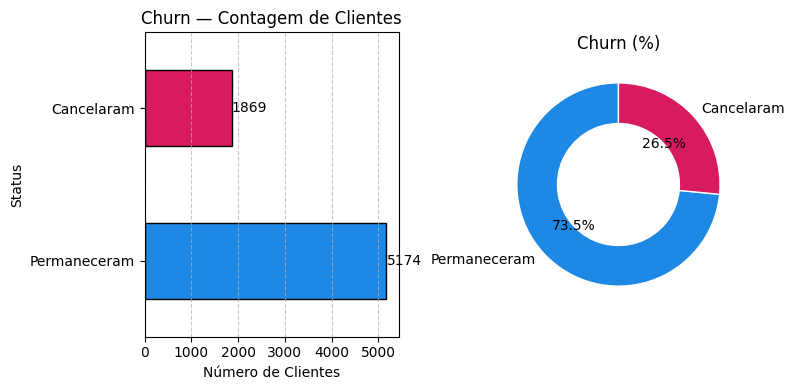

In [14]:
import matplotlib.pyplot as plt

# Contagem e porcentagem
churn_cnt = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

# Diminuindo as proporções
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Gráfico 1 — Barras horizontais
churn_cnt.plot(
    kind='barh',
    ax=axes[0],
    color=['#1E88E5', '#D81B60'],
    edgecolor='black'
)

for p in axes[0].patches:
    axes[0].annotate(
        f'{p.get_width():.0f}',
        (p.get_width(), p.get_y() + p.get_height() / 2),
        ha='left', va='center'
    )

axes[0].set(
    title='Churn — Contagem de Clientes',
    xlabel='Número de Clientes',
    ylabel='Status'
)
axes[0].set_yticklabels(['Permaneceram', 'Cancelaram'])
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# Gráfico 2 — Donut
axes[1].pie(
    churn_pct,
    labels=['Permaneceram', 'Cancelaram'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#1E88E5', '#D81B60'],
    wedgeprops=dict(width=0.4, edgecolor='white')
)

axes[1].set(title='Churn (%)', aspect='equal')

plt.tight_layout()
plt.show()

In [15]:
from IPython.display import Markdown, display

# Métricas principais de churn
churn_total = df.shape[0]
churn_cancelados = df['Churn'].sum()
churn_ativos = churn_total - churn_cancelados
churn_pct_cancelados = (churn_cancelados / churn_total) * 100

relatorio_churn_geral = f"""
## 🔹 Churn — Visão Geral

- 👥 Total de clientes: **{churn_total}**
- ❌ Cancelaram: **{churn_cancelados}**
- ✅ Permaneceram: **{churn_ativos}**
- 📉 Taxa de Churn: **{churn_pct_cancelados:.2f}%**

💡 Aproximadamente **{churn_pct_cancelados:.1f}%** dos clientes cancelaram,
mostrando que a evasão é um ponto crítico para a Telecom X.
"""

display(Markdown(relatorio_churn_geral))



## 🔹 Churn — Visão Geral

- 👥 Total de clientes: **7043**
- ❌ Cancelaram: **1869**
- ✅ Permaneceram: **5174**
- 📉 Taxa de Churn: **26.54%**

💡 Aproximadamente **26.5%** dos clientes cancelaram,
mostrando que a evasão é um ponto crítico para a Telecom X.


<Figure size 600x300 with 0 Axes>

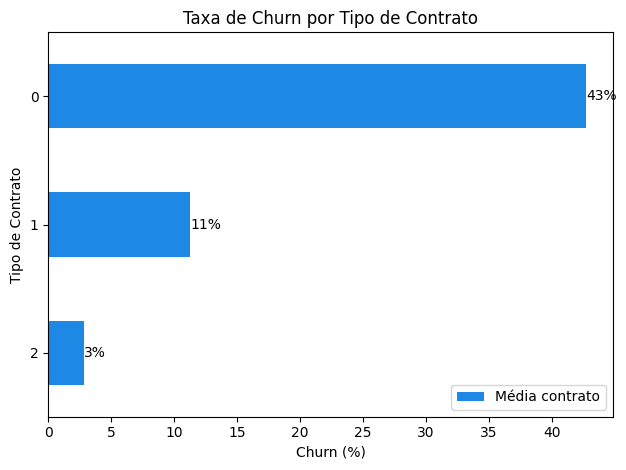

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3))
ax = churn_contrato.sort_values(by='Média contrato').plot(kind='barh', color='#1E88E5')

# Título e rótulos
ax.set(title='Taxa de Churn por Tipo de Contrato',
       xlabel='Churn (%)',
       ylabel='Tipo de Contrato')

# Adiciona valores nas barras
for p in ax.patches:
    ax.annotate(f'{p.get_width():.0f}%',
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center')

plt.tight_layout()
plt.show()

In [17]:
from IPython.display import Markdown, display

# Churn médio por tipo de contrato (%)
churn_contrato = df.groupby('account_Contract')['Churn'].mean() * 100

# Maior e menor churn
contrato_maior_churn = churn_contrato.idxmax()
contrato_menor_churn = churn_contrato.idxmin()
valor_maior_churn = churn_contrato.max()
valor_menor_churn = churn_contrato.min()

relatorio_churn_contrato = f"""
## 🔹 Churn em Tipo de Contrato

- 📉 Maior churn: **{contrato_maior_churn}** — **{valor_maior_churn:.2f}%**
- 📉 Menor churn: **{contrato_menor_churn}** — **{valor_menor_churn:.2f}%**

💡 Clientes com contrato **{contrato_maior_churn}** apresentam maior risco de evasão,
enquanto contratos de maior duração estão associados a menor churn.
"""

display(Markdown(relatorio_churn_contrato))



## 🔹 Churn em Tipo de Contrato

- 📉 Maior churn: **Month-to-month** — **42.71%**
- 📉 Menor churn: **Two year** — **2.83%**

💡 Clientes com contrato **Month-to-month** apresentam maior risco de evasão,
enquanto contratos de maior duração estão associados a menor churn.


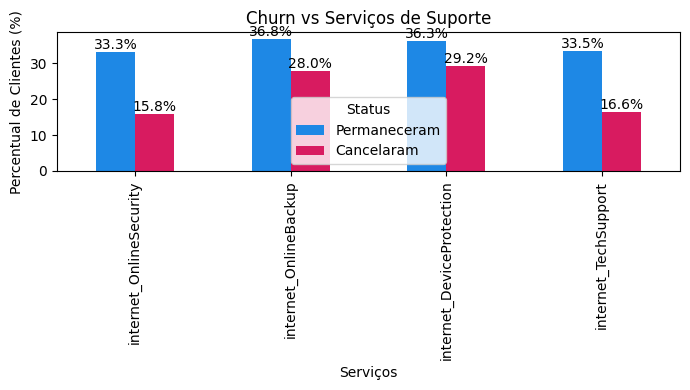

In [18]:
import matplotlib.pyplot as plt

# Serviços selecionados
servicos = [
    'internet_OnlineSecurity',
    'internet_OnlineBackup',
    'internet_DeviceProtection',
    'internet_TechSupport'
]

# Churn médio por serviço (%)
churn_servicos = df.groupby('Churn')[servicos].mean() * 100

# Gráfico de barras agrupadas
ax = churn_servicos.T.plot(
    kind='bar',
    figsize=(7,4),
    color=['#1E88E5', '#D81B60']
)

ax.set(
    title='Churn vs Serviços de Suporte',
    xlabel='Serviços',
    ylabel='Percentual de Clientes (%)'
)
ax.legend(['Permaneceram', 'Cancelaram'], title='Status')

# Adiciona valores nas barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [19]:
from IPython.display import Markdown, display

# Churn médio por serviço (%)
churn_servicos_medio = df.groupby('Churn')[servicos].mean() * 100

# Serviço com maior diferença
diferenca_servicos = churn_servicos_medio.loc[1] - churn_servicos_medio.loc[0]
servico_maior_risco = diferenca_servicos.idxmax()
valor_maior_risco = diferenca_servicos.max()

relatorio_churn_servicos = f"""
## 🔹 Churn em Serviços de Suporte

- ✅ Serviço com maior impacto no churn: **{servico_maior_risco}**
- 📉 Diferença entre cancelados e ativos: **{valor_maior_risco:.2f}%**

💡 O serviço **{servico_maior_risco}** concentra o maior risco de evasão,
mostrando que sua ausência ou baixo valor percebido está ligada ao aumento do churn.
"""

display(Markdown(relatorio_churn_servicos))



## 🔹 Churn em Serviços de Suporte

- ✅ Serviço com maior impacto no churn: **internet_DeviceProtection**
- 📉 Diferença entre cancelados e ativos: **-7.12%**

💡 O serviço **internet_DeviceProtection** concentra o maior risco de evasão,
mostrando que sua ausência ou baixo valor percebido está ligada ao aumento do churn.


<Figure size 700x400 with 0 Axes>

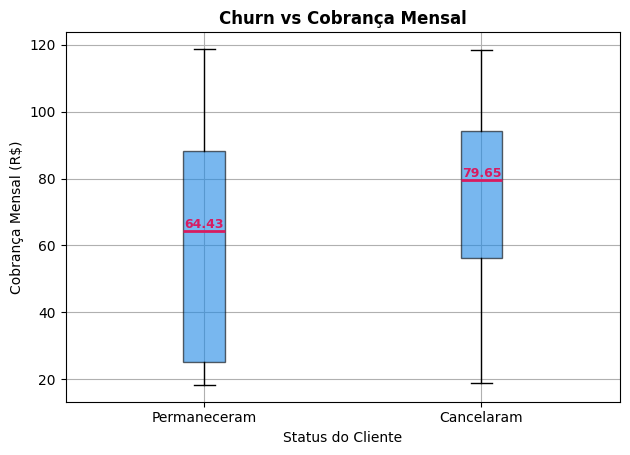

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
ax = df.boxplot(
    column='account_Charges_Monthly',
    by='Churn',
    grid=True,  # adiciona grade para facilitar leitura
    patch_artist=True,
    boxprops=dict(facecolor='#1E88E5', alpha=0.6, edgecolor='black'),
    medianprops=dict(color='#D81B60', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

# Títulos e rótulos
plt.title('Churn vs Cobrança Mensal', fontsize=12, fontweight='bold')
plt.suptitle('')
plt.xlabel('Status do Cliente')
plt.ylabel('Cobrança Mensal (R$)')
plt.xticks([1,2], ['Permaneceram', 'Cancelaram'])

# Adiciona valores das medianas com destaque
for i, median in enumerate(df.groupby('Churn')['account_Charges_Monthly'].median(), start=1):
    plt.text(i, median, f'{median:.2f}',
             ha='center', va='bottom',
             fontsize=9, fontweight='bold', color='#D81B60')

plt.tight_layout()
plt.show()


In [21]:
from IPython.display import Markdown, display

# Médias mensais por churn
media_mensal_churn = df.groupby('Churn')['account_Charges_Monthly'].mean()
media_perm = media_mensal_churn.loc[0]
media_cancel = media_mensal_churn.loc[1]
diferenca = media_cancel - media_perm

relatorio_churn_cobranca = f"""
## 🔹 Churn em Cobrança Mensal

- 💰 Média mensal (Permaneceram): R$ {media_perm:.2f}\n
- 💰 Média mensal (Cancelaram): R$ {media_cancel:.2f}\n
- 📉 Diferença: R$ {diferenca:.2f}

💡 Clientes que cancelaram pagam, em média, valores mais altos,
o que sugere que cobranças maiores podem estar ligadas à evasão.
"""

display(Markdown(relatorio_churn_cobranca))



## 🔹 Churn em Cobrança Mensal

- 💰 Média mensal (Permaneceram): R$ 61.27

- 💰 Média mensal (Cancelaram): R$ 74.44

- 📉 Diferença: R$ 13.18

💡 Clientes que cancelaram pagam, em média, valores mais altos,
o que sugere que cobranças maiores podem estar ligadas à evasão.


In [22]:
from IPython.display import Markdown, display

relatorio_conclusao = f"""
# 📄 Análise de Churn — Telecom X

### Principais Fatores
- 📊 Taxa de Churn: **({churn_pct_cancelados:.2f}%)**
- 📄 Contrato maior Churn: **{contrato_maior_churn}** ({valor_maior_churn:.2f}%)
- 📄 Serviços criteriosos: **{servico_maior_risco}** (diferença de {valor_maior_risco:.2f}%)

### Insights
- 📄Contratos de curto prazo têm maior risco de evasão.
- 📄Serviços de suporte específicos influenciam retenção.
- 📊Cobranças mensais mais altas aumentam probabilidade de cancelamento.

### Próximos Passos
- 📄Focar retenção em contratos curtos e serviços críticos.
- 📉Avaliar preços e benefícios para clientes com cobranças altas.
- 💡Utilizar as variáveis em modelos preditivos.

---

💡 Criado por: **Silvia Galvão**
"""

display(Markdown(relatorio_conclusao))



# 📄 Análise de Churn — Telecom X

### Principais Fatores
- 📊 Taxa de Churn: **(26.54%)**
- 📄 Contrato maior Churn: **Month-to-month** (42.71%)
- 📄 Serviços criteriosos: **internet_DeviceProtection** (diferença de -7.12%)

### Insights
- 📄Contratos de curto prazo têm maior risco de evasão.
- 📄Serviços de suporte específicos influenciam retenção.
- 📊Cobranças mensais mais altas aumentam probabilidade de cancelamento.

### Próximos Passos
- 📄Focar retenção em contratos curtos e serviços críticos.
- 📉Avaliar preços e benefícios para clientes com cobranças altas.
- 💡Utilizar as variáveis em modelos preditivos.

---

💡 Criado por: **Silvia Galvão**
